<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/SumofTotalPAR_Daily_Forecasting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor, callback
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('/content/lag_data.csv')

columns_to_take = [
    'Date',
    'SumofTotalPAR'
]

data_df = df[columns_to_take].copy()

In [3]:
data_df['Date'] = pd.to_datetime(data_df['Date'], dayfirst=True)

grouped_df = data_df.groupby('Date').sum().reset_index()
grouped_df = grouped_df.sort_values('Date')

In [4]:
upper = grouped_df['SumofTotalPAR'].quantile(0.99)
grouped_df['SumofTotalPAR'] = np.clip(
    grouped_df['SumofTotalPAR'],
    None,
    upper
)

In [5]:
grouped_df['lag_1'] = grouped_df['SumofTotalPAR'].shift(1)
grouped_df['lag_2'] = grouped_df['SumofTotalPAR'].shift(2)
grouped_df['lag_3'] = grouped_df['SumofTotalPAR'].shift(3)
grouped_df['lag_7'] = grouped_df['SumofTotalPAR'].shift(7)
grouped_df['lag_14'] = grouped_df['SumofTotalPAR'].shift(14)
grouped_df['lag_30'] = grouped_df['SumofTotalPAR'].shift(30)

grouped_df['ema_7'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=7).mean()
grouped_df['ema_14'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=14).mean()
grouped_df['ema_30'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=30).mean()

grouped_df['diff_1'] = grouped_df['SumofTotalPAR'].diff(1)
grouped_df['diff_7'] = grouped_df['SumofTotalPAR'].diff(7)
grouped_df['pct_change_1'] = grouped_df['SumofTotalPAR'].pct_change(1)

grouped_df['day'] = grouped_df['Date'].dt.day
grouped_df['month'] = grouped_df['Date'].dt.month
grouped_df['dayofweek'] = grouped_df['Date'].dt.dayofweek
grouped_df['weekofyear'] = grouped_df['Date'].dt.isocalendar().week.astype(int)

grouped_df['sin_week'] = np.sin(2 * np.pi * grouped_df['dayofweek'] / 7)
grouped_df['cos_week'] = np.cos(2 * np.pi * grouped_df['dayofweek'] / 7)

In [6]:
grouped_df = grouped_df.dropna().reset_index(drop=True)
grouped_df['target'] = grouped_df['SumofTotalPAR']

In [7]:
features = [
    'lag_1','lag_2','lag_3','lag_7','lag_14','lag_30',
    'ema_7','ema_14','ema_30',
    'diff_1','diff_7','pct_change_1',
    'day','month','weekofyear',
    'sin_week','cos_week'
]

In [8]:
train_df = grouped_df[grouped_df['Date'] < '2026-04-01']
test_df = grouped_df[grouped_df['Date'] >= '2026-04-01']

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

In [9]:
model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

In [15]:
model.fit(
    X_train,
    y_train,
    # eval_set=[(X_test, y_test)],
    verbose=True
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
preds = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print("\n====================")
print("MODEL PERFORMANCE")
print("====================")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


MODEL PERFORMANCE
MAE : 16,137,866.34
RMSE: 29,118,947.04
MAPE: 0.95%


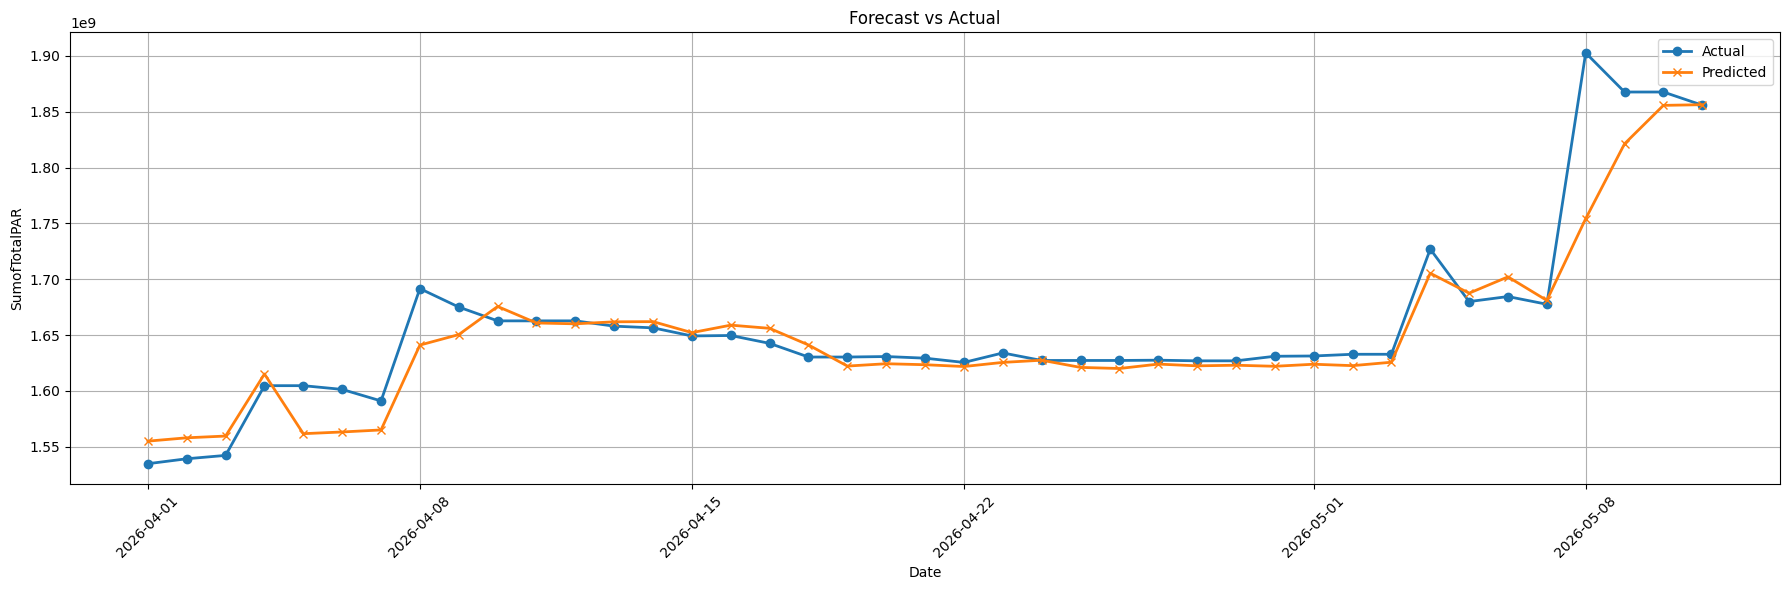

In [18]:
plt.figure(figsize=(18,6))

plt.plot(test_df['Date'], y_test, label='Actual', linewidth=2, marker='o')
plt.plot(test_df['Date'], preds, label='Predicted', linewidth=2, marker='x')

plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("SumofTotalPAR")

plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Feature Importance:
         Feature  Importance
4         lag_14    0.312263
3          lag_7    0.230198
6          ema_7    0.227215
0          lag_1    0.091345
7         ema_14    0.060781
2          lag_3    0.057120
1          lag_2    0.019368
5         lag_30    0.000982
14    weekofyear    0.000388
10        diff_7    0.000209
8         ema_30    0.000073
9         diff_1    0.000026
11  pct_change_1    0.000018
13         month    0.000008
12           day    0.000002
15      sin_week    0.000002
16      cos_week    0.000002


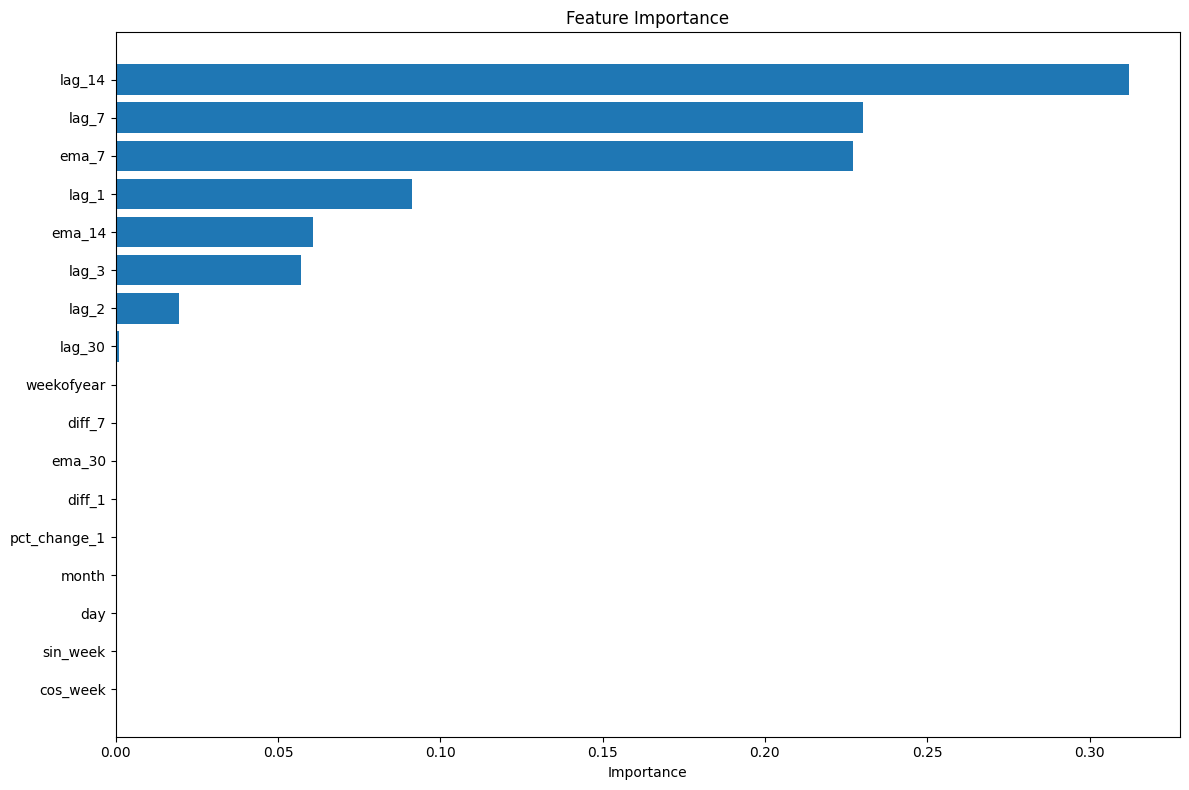

In [19]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance')

plt.xlabel('Importance')

plt.tight_layout()

plt.show()

[0]	validation_0-rmse:707835543.91771
[100]	validation_0-rmse:163247055.93400
[200]	validation_0-rmse:62998117.21114
[300]	validation_0-rmse:48613576.89114
[400]	validation_0-rmse:46582157.79950
[500]	validation_0-rmse:46507812.47705
[600]	validation_0-rmse:46554664.26061
[628]	validation_0-rmse:46549526.10364

MODEL PERFORMANCE
MAE : 23,560,366.00
RMSE: 46,430,222.41
MAPE: 1.3648%


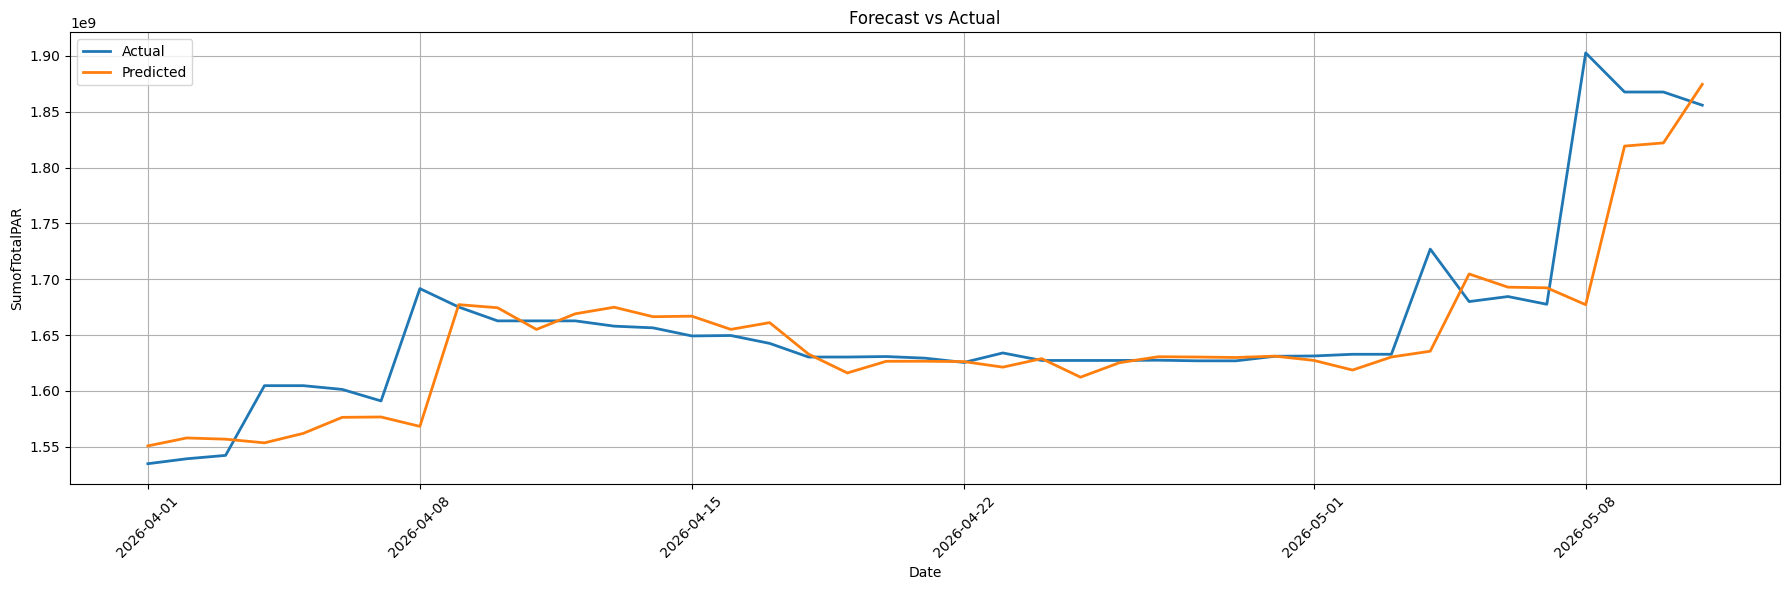


Feature Importance:
            Feature  Importance
4            lag_14    0.252077
0             lag_1    0.234225
2             lag_3    0.118818
7    rolling_mean_7    0.111832
8   rolling_mean_14    0.103047
3             lag_7    0.087119
1             lag_2    0.053954
6    rolling_mean_3    0.026751
5            lag_30    0.011207
17       weekofyear    0.000482
14           diff_7    0.000120
9   rolling_mean_30    0.000113
11           ema_14    0.000071
10            ema_7    0.000056
12           ema_30    0.000042
16            month    0.000025
18         sin_week    0.000019
13           diff_1    0.000016
15        dayofweek    0.000014
19         cos_week    0.000012


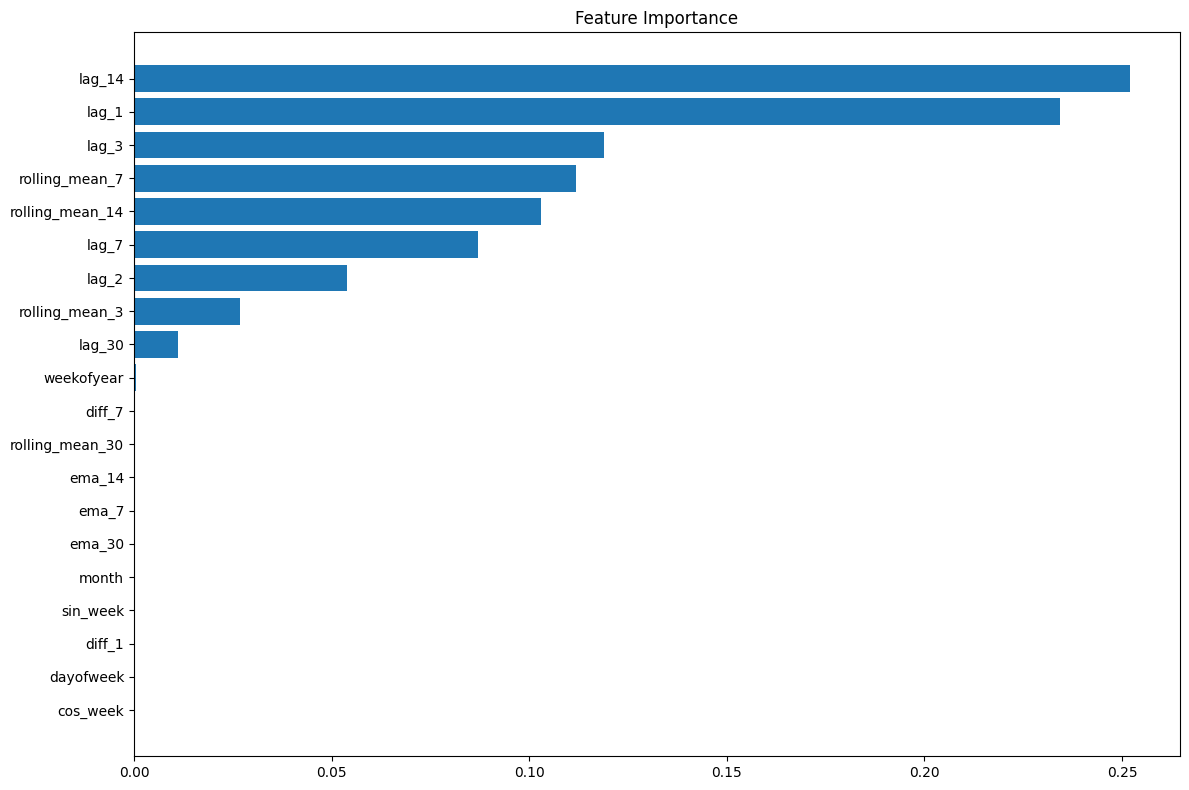

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv('/content/lag_data.csv')

data_df = df[['Date', 'SumofTotalPAR']].copy()

# =========================================================
# DATE
# =========================================================

data_df['Date'] = pd.to_datetime(
    data_df['Date'],
    dayfirst=True
)

grouped_df = (
    data_df
    .groupby('Date')
    .sum()
    .reset_index()
    .sort_values('Date')
)

# =========================================================
# OUTLIER CAPPING
# =========================================================

upper = grouped_df['SumofTotalPAR'].quantile(0.995)

grouped_df['SumofTotalPAR'] = np.clip(
    grouped_df['SumofTotalPAR'],
    None,
    upper
)

# =========================================================
# TARGET
# =========================================================

grouped_df['target'] = grouped_df['SumofTotalPAR']

# =========================================================
# LAGS
# =========================================================

lags = [1,2,3,7,14,30]

for lag in lags:
    grouped_df[f'lag_{lag}'] = (
        grouped_df['target'].shift(lag)
    )

# =========================================================
# ROLLING MEAN
# =========================================================

windows = [3,7,14,30]

for w in windows:

    grouped_df[f'rolling_mean_{w}'] = (
        grouped_df['target']
        .shift(1)
        .rolling(w)
        .mean()
    )

# =========================================================
# EMA
# =========================================================

for span in [7,14,30]:

    grouped_df[f'ema_{span}'] = (
        grouped_df['target']
        .shift(1)
        .ewm(span=span)
        .mean()
    )

# =========================================================
# SAFE DIFFERENCE FEATURES
# =========================================================

grouped_df['diff_1'] = (
    grouped_df['target']
    .shift(1)
    .diff(1)
)

grouped_df['diff_7'] = (
    grouped_df['target']
    .shift(1)
    .diff(7)
)

# =========================================================
# DATE FEATURES
# =========================================================

grouped_df['dayofweek'] = (
    grouped_df['Date']
    .dt.dayofweek
)

grouped_df['month'] = (
    grouped_df['Date']
    .dt.month
)

grouped_df['weekofyear'] = (
    grouped_df['Date']
    .dt.isocalendar()
    .week
    .astype(int)
)

# =========================================================
# CYCLICAL FEATURES
# =========================================================

grouped_df['sin_week'] = np.sin(
    2 * np.pi * grouped_df['dayofweek'] / 7
)

grouped_df['cos_week'] = np.cos(
    2 * np.pi * grouped_df['dayofweek'] / 7
)

# =========================================================
# DROP NULLS
# =========================================================

grouped_df = grouped_df.dropna().reset_index(drop=True)

# =========================================================
# FEATURES
# =========================================================

features = [

    # LAGS
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_30',

    # ROLLING
    'rolling_mean_3',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',

    # EMA
    'ema_7',
    'ema_14',
    'ema_30',

    # DIFFERENCE
    'diff_1',
    'diff_7',

    # DATE
    'dayofweek',
    'month',
    'weekofyear',

    # CYCLICAL
    'sin_week',
    'cos_week'
]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_df = grouped_df[
    grouped_df['Date'] < '2026-04-01'
]

test_df = grouped_df[
    grouped_df['Date'] >= '2026-04-01'
]

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

# =========================================================
# MODEL
# =========================================================

model = XGBRegressor(

    n_estimators=2500,
    learning_rate=0.015,

    max_depth=5,
    min_child_weight=5,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.5,
    reg_lambda=2,

    gamma=0.1,

    objective='reg:squarederror',

    random_state=42,

    early_stopping_rounds=150
)

# =========================================================
# TRAIN
# =========================================================

model.fit(
    X_train,
    y_train,

    eval_set=[(X_test, y_test)],

    verbose=100
)

# =========================================================
# PREDICTIONS
# =========================================================

preds = model.predict(X_test)

# =========================================================
# METRICS
# =========================================================

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

mape = np.mean(
    np.abs(
        (y_test - preds) / y_test
    )
) * 100

# =========================================================
# RESULTS
# =========================================================

print("\n====================")
print("MODEL PERFORMANCE")
print("====================")

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.4f}%")

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    test_df['Date'],
    y_test,
    label='Actual',
    linewidth=2
)

plt.plot(
    test_df['Date'],
    preds,
    label='Predicted',
    linewidth=2
)

plt.title("Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("SumofTotalPAR")

plt.legend()
plt.grid()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    'Feature': features,
    'Importance': model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(12,8))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Number of data points in the train set: 1083, number of used features: 8
[LightGBM] [Info] Start training from score 931119517.724838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

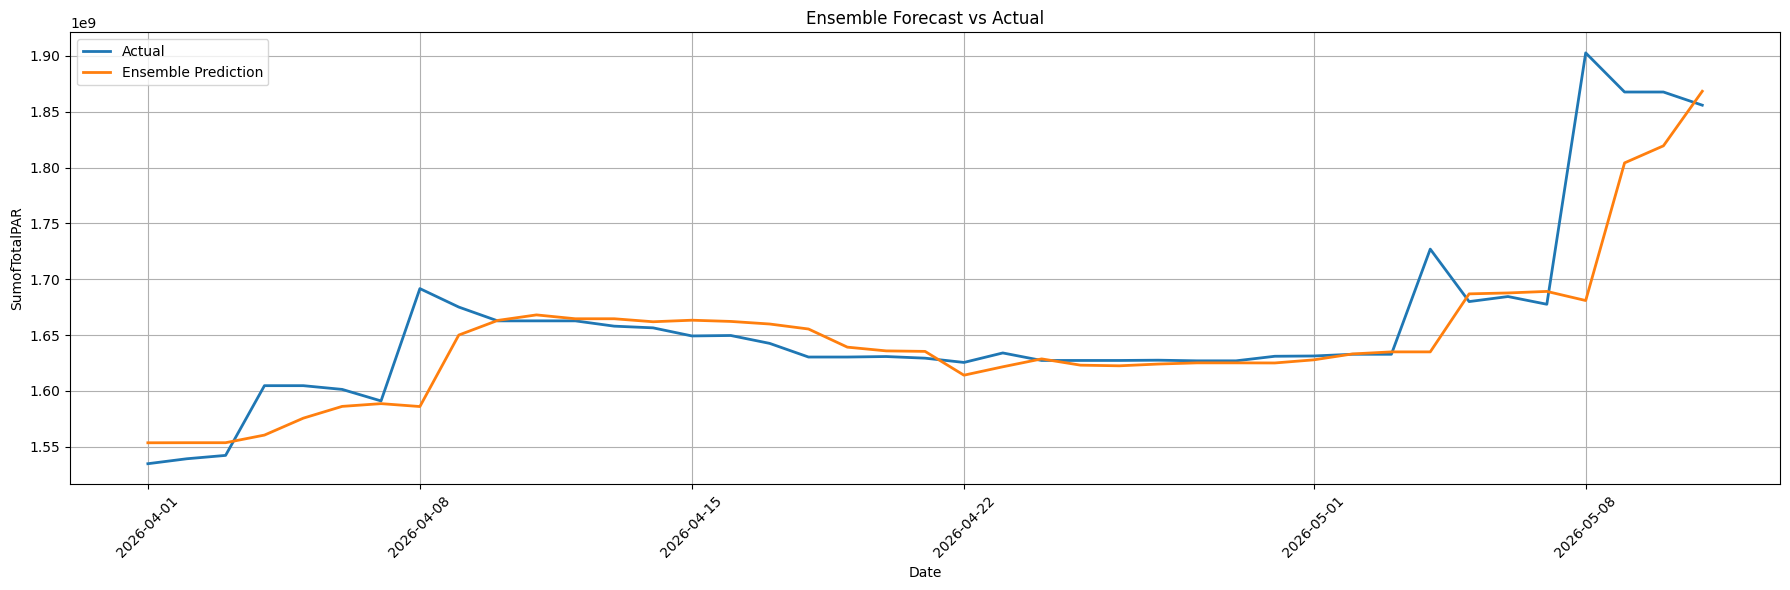

In [33]:
# =========================================================
# INSTALL (run once)
# =========================================================

!pip install optuna
!pip install lightgbm catboost

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv('/content/lag_data.csv')

data_df = df[['Date', 'SumofTotalPAR']].copy()

data_df['Date'] = pd.to_datetime(data_df['Date'], dayfirst=True)

grouped_df = (
    data_df
    .groupby('Date')
    .sum()
    .reset_index()
    .sort_values('Date')
)

# =========================================================
# OUTLIER HANDLING
# =========================================================

upper = grouped_df['SumofTotalPAR'].quantile(0.99)

grouped_df['SumofTotalPAR'] = np.clip(
    grouped_df['SumofTotalPAR'],
    None,
    upper
)

# =========================================================
# TARGET
# =========================================================

grouped_df['target'] = grouped_df['SumofTotalPAR']

# =========================================================
# FEATURES (your best proven set)
# =========================================================

grouped_df['lag_1'] = grouped_df['target'].shift(1)
grouped_df['lag_2'] = grouped_df['target'].shift(2)
grouped_df['lag_3'] = grouped_df['target'].shift(3)
grouped_df['lag_7'] = grouped_df['target'].shift(7)
grouped_df['lag_14'] = grouped_df['target'].shift(14)

grouped_df['ema_7'] = grouped_df['target'].shift(1).ewm(span=7).mean()

grouped_df['rolling_mean_3'] = grouped_df['target'].shift(1).rolling(3).mean()
grouped_df['rolling_mean_7'] = grouped_df['target'].shift(1).rolling(7).mean()

grouped_df = grouped_df.dropna().reset_index(drop=True)

features = [
    'lag_1','lag_2','lag_3',
    'lag_7','lag_14',
    'ema_7',
    'rolling_mean_3','rolling_mean_7'
]

# =========================================================
# SPLIT
# =========================================================

train_df = grouped_df[grouped_df['Date'] < '2026-04-01']
test_df  = grouped_df[grouped_df['Date'] >= '2026-04-01']

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

# =========================================================
# MODELS
# =========================================================

xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=3,
    random_state=42
)

lgb_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.01,
    depth=4,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

# =========================================================
# TRAIN MODELS
# =========================================================

xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================

xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)
cat_preds = cat_model.predict(X_test)

# =========================================================
# ENSEMBLE (AVERAGE)
# =========================================================

final_preds = (xgb_preds + lgb_preds + cat_preds) / 3

# =========================================================
# METRICS
# =========================================================

mae = mean_absolute_error(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))

mape = np.mean(
    np.abs((y_test - final_preds) / y_test)
) * 100

print("\n====================")
print("ENSEMBLE PERFORMANCE")
print("====================")

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.4f}%")

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(test_df['Date'], y_test, label='Actual', linewidth=2)
plt.plot(test_df['Date'], final_preds, label='Ensemble Prediction', linewidth=2)

plt.title("Ensemble Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("SumofTotalPAR")

plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [35]:
import pandas as pd
import numpy as np
import optuna

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_csv('/content/lag_data.csv')

data_df = df[['Date', 'SumofTotalPAR']].copy()

data_df['Date'] = pd.to_datetime(
    data_df['Date'],
    dayfirst=True
)

grouped_df = (
    data_df
    .groupby('Date')
    .sum()
    .reset_index()
    .sort_values('Date')
)

# ======================================================
# OUTLIER CAPPING
# ======================================================

upper = grouped_df['SumofTotalPAR'].quantile(0.99)

grouped_df['SumofTotalPAR'] = np.clip(
    grouped_df['SumofTotalPAR'],
    None,
    upper
)

# ======================================================
# ORIGINAL FEATURES
# ======================================================

grouped_df['lag_1'] = grouped_df['SumofTotalPAR'].shift(1)
grouped_df['lag_2'] = grouped_df['SumofTotalPAR'].shift(2)
grouped_df['lag_3'] = grouped_df['SumofTotalPAR'].shift(3)
grouped_df['lag_7'] = grouped_df['SumofTotalPAR'].shift(7)
grouped_df['lag_14'] = grouped_df['SumofTotalPAR'].shift(14)
grouped_df['lag_30'] = grouped_df['SumofTotalPAR'].shift(30)

grouped_df['ema_7'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .ewm(span=7)
    .mean()
)

grouped_df['ema_14'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .ewm(span=14)
    .mean()
)

grouped_df['ema_30'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .ewm(span=30)
    .mean()
)

grouped_df['diff_1'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .diff(1)
)

grouped_df['diff_7'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .diff(7)
)

grouped_df['pct_change_1'] = (
    grouped_df['SumofTotalPAR']
    .shift(1)
    .pct_change(1)
)

grouped_df['day'] = grouped_df['Date'].dt.day
grouped_df['month'] = grouped_df['Date'].dt.month
grouped_df['dayofweek'] = grouped_df['Date'].dt.dayofweek
grouped_df['weekofyear'] = grouped_df['Date'].dt.isocalendar().week.astype(int)

grouped_df['sin_week'] = np.sin(
    2 * np.pi * grouped_df['dayofweek'] / 7
)

grouped_df['cos_week'] = np.cos(
    2 * np.pi * grouped_df['dayofweek'] / 7
)

grouped_df = grouped_df.dropna().reset_index(drop=True)

grouped_df['target'] = grouped_df['SumofTotalPAR']

# ======================================================
# FEATURES
# ======================================================

features = [
    'lag_1','lag_2','lag_3',
    'lag_7','lag_14','lag_30',

    'ema_7','ema_14','ema_30',

    'diff_1','diff_7','pct_change_1',

    'day','month','weekofyear',

    'sin_week','cos_week'
]

# ======================================================
# SPLIT
# ======================================================

train_df = grouped_df[
    grouped_df['Date'] < '2026-04-01'
]

test_df = grouped_df[
    grouped_df['Date'] >= '2026-04-01'
]

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

# ======================================================
# OPTUNA OBJECTIVE
# ======================================================

def objective(trial):

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            300,
            3000
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.05
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            8
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            10
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'gamma': trial.suggest_float(
            'gamma',
            0,
            1
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0,
            5
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0,
            5
        ),

        'objective': 'reg:squarederror',

        'random_state': 42
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)

    mape = np.mean(
        np.abs(
            (y_test - preds) / y_test
        )
    ) * 100

    return mape

# ======================================================
# RUN OPTUNA
# ======================================================

study = optuna.create_study(
    direction='minimize'
)

study.optimize(
    objective,
    n_trials=50
)

# ======================================================
# BEST RESULTS
# ======================================================

print("\n======================")
print("BEST PARAMETERS")
print("======================")

print(study.best_params)

print("\n======================")
print("BEST MAPE")
print("======================")

print(study.best_value)

[I 2026-05-16 07:09:39,706] A new study created in memory with name: no-name-3e3c40f7-6832-40ba-8bc4-cb8e7b85c647
[I 2026-05-16 07:09:43,194] Trial 0 finished with value: 1.0848288630655651 and parameters: {'n_estimators': 873, 'learning_rate': 0.04868208792022755, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.6496046842574811, 'colsample_bytree': 0.960356178942641, 'gamma': 0.06726110110197003, 'reg_alpha': 2.38135802591935, 'reg_lambda': 1.2504431388119914}. Best is trial 0 with value: 1.0848288630655651.
[I 2026-05-16 07:09:46,171] Trial 1 finished with value: 1.128788818665206 and parameters: {'n_estimators': 2205, 'learning_rate': 0.005436110922018888, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6576677080075134, 'colsample_bytree': 0.7282548977543062, 'gamma': 0.17615442246160773, 'reg_alpha': 0.3992456461793953, 'reg_lambda': 3.2619535284210492}. Best is trial 0 with value: 1.0848288630655651.
[I 2026-05-16 07:09:49,022] Trial 2 finished with value: 1.153765406


BEST PARAMETERS
{'n_estimators': 2934, 'learning_rate': 0.03227362719767998, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7132053491500562, 'colsample_bytree': 0.882118280895524, 'gamma': 0.8399755377532062, 'reg_alpha': 0.8380009810581351, 'reg_lambda': 0.7696555685076453}

BEST MAPE
0.9968268859455405
